<a href="https://colab.research.google.com/github/Luthfifauzan28/Apparel-APP/blob/main/02_crisp_dm_prediksi_curah_hujan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 — Prediksi Curah Hujan Kota Sukabumi (Random Forest)
### Metodologi CRISP-DM — Data Understanding s/d Deployment

Notebook ini mencakup fase CRISP-DM: Business Understanding, Data Understanding, Data Preparation (lengkap: Select, Clean, Construct, Format Data), Modeling, Evaluation, dan Deployment. Proses transformasi raw BMKG → dataset gabungan **tidak** ada di sini — itu ada di `01_transformasi_data_bmkg.ipynb`, dan notebook ini murni mengolah hasilnya (`dataset_bmkg_2020_2025.csv`) melalui pipeline CRISP-DM yang berdiri sendiri (tidak berasumsi datanya sudah bersih).

---
# FASE 1 — Business Understanding

**Tujuan bisnis/penelitian:** membangun model prediksi curah hujan harian (RR, dalam mm) di Kota Sukabumi menggunakan algoritma Random Forest, berdasarkan variabel cuaca harian (suhu, kelembapan, penyinaran matahari, kecepatan angin).

**Tujuan data mining:** regresi — memprediksi nilai numerik RR dari fitur cuaca lain, dievaluasi dengan MAE, RMSE, dan R².

**Kriteria keberhasilan:** model dengan R² setinggi mungkin pada data uji, terutama pada subset **BMKG_OBSERVASI** (data pengukuran langsung) — karena itu yang mencerminkan performa di dunia nyata, bukan pada data hasil augmentasi statistik.

---
# FASE 2 — Data Understanding

## 2.1 Import Library

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 2.2 Pengumpulan Data (Collect Initial Data)

Data yang dipakai adalah hasil Notebook 1: `dataset_bmkg_2020_2025.csv`, rentang 2020–2025. Kolom `SUMBER` menandai `BMKG_OBSERVASI` (pengukuran langsung) vs `BMKG_AUGMENTASI` (estimasi statistik berbasis pola BMKG_OBSERVASI).

In [22]:
DATA_PATH = 'dataset_bmkg_2020_2025.csv'

df_raw2 = pd.read_csv(DATA_PATH)
df_raw2['TANGGAL'] = pd.to_datetime(df_raw2['TANGGAL'])
df_raw2 = df_raw2.sort_values('TANGGAL').reset_index(drop=True)

print('Jumlah baris:', len(df_raw2))
print('Rentang tanggal:', df_raw2['TANGGAL'].min().date(), '-', df_raw2['TANGGAL'].max().date())
df_raw2.head()


Jumlah baris: 2194
Rentang tanggal: 2020-01-01 - 2026-01-01


,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,FF_AVG,SUMBER
0,2020-01-01,22.3,30.5,26.5,86.1,4.6,2.0,8,2,BMKG_AUGMENTASI
1,2020-01-02,24.0,29.3,25.1,93.0,15.1,4.2,11,2,BMKG_AUGMENTASI
2,2020-01-03,22.9,33.6,26.6,79.7,15.3,5.6,8,3,BMKG_AUGMENTASI
3,2020-01-04,23.6,32.0,26.7,86.2,5.4,0.1,8,3,BMKG_AUGMENTASI
4,2020-01-05,23.1,30.9,26.0,84.6,1.0,5.0,5,1,BMKG_AUGMENTASI


## 2.3 Deskripsi dan Verifikasi Kualitas Data (Describe & Verify Data Quality)

In [23]:
df_raw2.info()
print()
print('Missing value per kolom:')
print(df_raw2.isna().sum())
print()
print('Duplikat TANGGAL:', df_raw2['TANGGAL'].duplicated().sum())
print()
print('Proporsi SUMBER:')
print(df_raw2['SUMBER'].value_counts())
print(df_raw2['SUMBER'].value_counts(normalize=True).round(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2194 entries, 0 to 2193
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   TANGGAL  2194 non-null   datetime64[ns]
 1   TN       2194 non-null   float64       
 2   TX       2194 non-null   float64       
 3   TAVG     2194 non-null   float64       
 4   RH_AVG   2194 non-null   float64       
 5   RR       2194 non-null   float64       
 6   SS       2194 non-null   float64       
 7   FF_X     2194 non-null   int64         
 8   FF_AVG   2194 non-null   int64         
 9   SUMBER   2194 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 171.5+ KB

Missing value per kolom:
TANGGAL    0
TN         0
TX         0
TAVG       0
RH_AVG     0
RR         0
SS         0
FF_X       0
FF_AVG     0
SUMBER     0
dtype: int64

Duplikat TANGGAL: 1

Proporsi SUMBER:
SUMBER
BMKG_AUGMENTASI    1645
BMKG_OBSERVASI      549
Name: c

In [24]:
numeric_cols = ['TN', 'TX', 'TAVG', 'RH_AVG', 'RR', 'SS', 'FF_X', 'FF_AVG']
df_raw2[numeric_cols].describe()


,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,FF_AVG
count,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000
mean,22.909298,32.092571,26.385005,83.988605,10.335346,5.015953,8.797174,2.170921
std,0.923921,1.595418,0.855682,5.262405,18.176693,2.568479,3.484625,0.826186
min,18.500000,25.800000,23.300000,65.000000,0.000000,0.000000,2.000000,0.000000
25%,22.400000,31.200000,25.800000,80.900000,0.025000,3.100000,6.000000,2.000000
50%,23.000000,32.400000,26.400000,84.500000,2.300000,5.500000,8.000000,2.000000
75%,23.500000,33.200000,27.000000,87.700000,11.575000,7.400000,11.000000,3.000000
max,25.200000,35.900000,28.800000,96.900000,130.800000,8.000000,24.000000,7.000000


## 2.4 Deteksi Potensi Anomali

Meskipun dataset ini sudah melalui pembersihan di Notebook 1, verifikasi ulang tetap dilakukan di sini secara independen — memeriksa apakah ada nilai yang secara fisik tidak masuk akal (mis. RH di luar 0–100%, RR negatif, kode error BMKG yang mungkin lolos).

In [25]:
anomali = {
    'RR negatif': (df_raw2['RR'] < 0).sum(),
    'RH_AVG di luar 0-100': ((df_raw2['RH_AVG'] < 0) | (df_raw2['RH_AVG'] > 100)).sum(),
    'SS negatif': (df_raw2['SS'] < 0).sum(),
    'Kode error BMKG (8888/9999) tersisa': df_raw2[numeric_cols].isin([8888, 9999]).sum().sum(),
}
for k, v in anomali.items():
    print(f'{k}: {v} baris')


RR negatif: 0 baris
RH_AVG di luar 0-100: 0 baris
SS negatif: 0 baris
Kode error BMKG (8888/9999) tersisa: 0 baris


## 2.5 Eksplorasi Visual

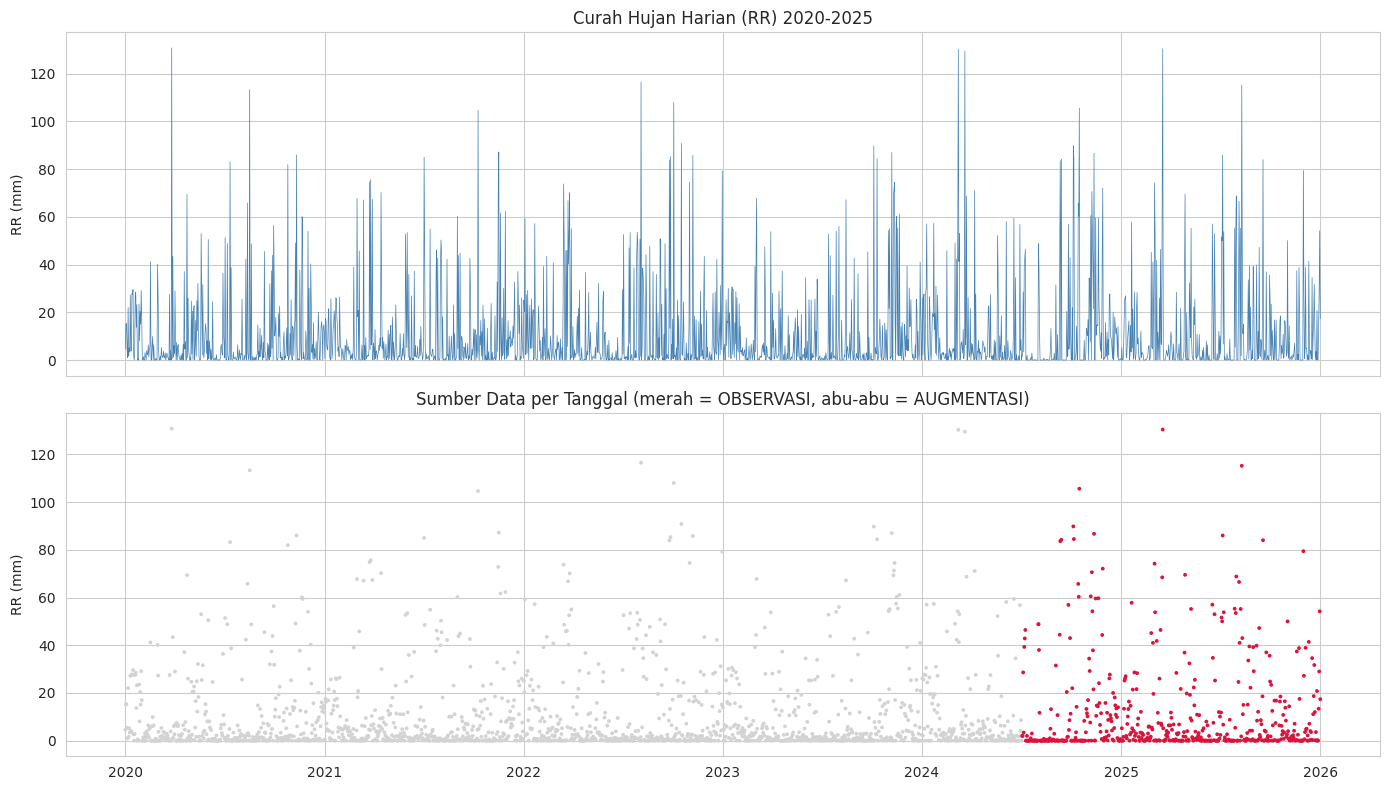

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df_raw2['TANGGAL'], df_raw2['RR'], linewidth=0.5, color='steelblue')
axes[0].set_title('Curah Hujan Harian (RR) 2020-2025')
axes[0].set_ylabel('RR (mm)')

warna = df_raw2['SUMBER'].map({'BMKG_OBSERVASI': 'crimson', 'BMKG_AUGMENTASI': 'lightgray'})
axes[1].scatter(df_raw2['TANGGAL'], df_raw2['RR'], c=warna, s=3)
axes[1].set_title('Sumber Data per Tanggal (merah = OBSERVASI, abu-abu = AUGMENTASI)')
axes[1].set_ylabel('RR (mm)')
plt.tight_layout()
plt.show()


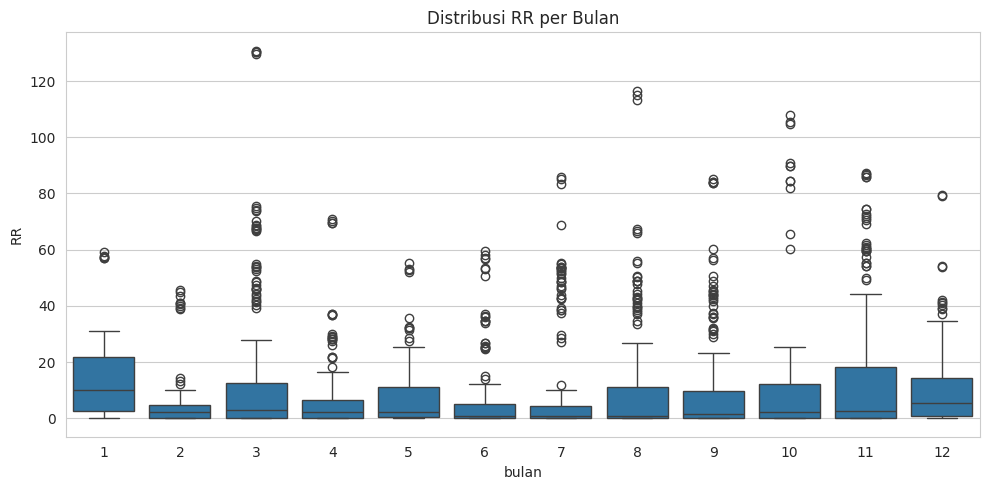

In [27]:
# Distribusi RR per Bulan
df_raw2['bulan'] = df_raw2['TANGGAL'].dt.month

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=df_raw2, x='bulan', y='RR', ax=ax)

ax.set_title('Distribusi RR per Bulan')
plt.tight_layout()
plt.show()


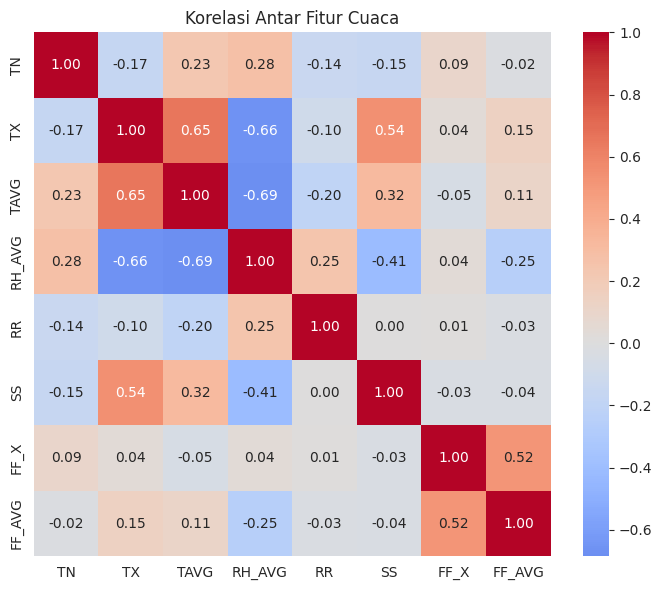

In [28]:
# Korelasi Antar Fitur
corr = df_raw2[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax
)

ax.set_title('Korelasi Antar Fitur Cuaca')
plt.tight_layout()
plt.show()

**Catatan Data Understanding:**
- Dataset lengkap 2020-2025 (2194 baris).
- ±75% baris `BMKG_AUGMENTASI`, ±25% `BMKG_OBSERVASI` — akan terus dipantau di fase Evaluation.
- Tidak ditemukan anomali fisik pada pengecekan 2.4 (hasil pembersihan Notebook 1 konsisten).

---
# FASE 3 — Data Preparation

Fase ini mengikuti sub-tahapan standar CRISP-DM: **Select Data → Clean Data → Construct Data → Format Data**, dikerjakan secara independen di notebook ini (tidak berasumsi input sudah "siap pakai").

## 3.1 Select Data

Memilih kolom yang relevan untuk pemodelan. Kolom `TANGGAL` dan `SUMBER` disimpan sebagai metadata (bukan fitur model), kolom cuaca numerik dipakai sebagai kandidat fitur, `RR` sebagai target.

In [29]:
kolom_metadata = ['TANGGAL', 'SUMBER']
kolom_fitur_mentah = ['TN', 'TX', 'TAVG', 'RH_AVG', 'SS', 'FF_X', 'FF_AVG']
kolom_target = 'RR'

df_select = df_raw2[kolom_metadata + kolom_fitur_mentah + [kolom_target]].copy()
df_select.head()


,TANGGAL,SUMBER,TN,TX,TAVG,RH_AVG,SS,FF_X,FF_AVG,RR
0,2020-01-01,BMKG_AUGMENTASI,22.3,30.5,26.5,86.1,2.0,8,2,4.6
1,2020-01-02,BMKG_AUGMENTASI,24.0,29.3,25.1,93.0,4.2,11,2,15.1
2,2020-01-03,BMKG_AUGMENTASI,22.9,33.6,26.6,79.7,5.6,8,3,15.3
3,2020-01-04,BMKG_AUGMENTASI,23.6,32.0,26.7,86.2,0.1,8,3,5.4
4,2020-01-05,BMKG_AUGMENTASI,23.1,30.9,26.0,84.6,5.0,5,1,1.0


## 3.2 Clean Data

Langkah pembersihan dijalankan ulang secara eksplisit di notebook ini:
1. Hapus duplikat tanggal (bila ada).
2. Ubah kode error BMKG (`8888`/`9999`) menjadi `NaN` (jaga-jaga bila ada yang lolos).
3. Clip nilai ke rentang fisik yang valid (RH 0–100%, RR ≥ 0, SS ≥ 0).
4. Imputasi missing value dengan interpolasi waktu.

In [30]:
df_clean2 = df_select.copy()

# 1. Hapus duplikat tanggal
n_dup = df_clean2['TANGGAL'].duplicated().sum()
df_clean2 = df_clean2.drop_duplicates(subset='TANGGAL', keep='first')
print(f'Duplikat tanggal dihapus: {n_dup}')

# 2. Kode error BMKG -> NaN
MISSING_CODES = [8888, 9999]
for col in kolom_fitur_mentah + [kolom_target]:
    n_bad = df_clean2[col].isin(MISSING_CODES).sum()
    if n_bad > 0:
        print(f'{col}: {n_bad} kode error BMKG diubah jadi NaN')
    df_clean2[col] = df_clean2[col].replace(MISSING_CODES, np.nan)

# 3. Clip ke rentang fisik valid
df_clean2['RH_AVG'] = df_clean2['RH_AVG'].clip(lower=0, upper=100)
df_clean2['RR'] = df_clean2['RR'].clip(lower=0)
df_clean2['SS'] = df_clean2['SS'].clip(lower=0, upper=24)

# 4. Imputasi missing value (interpolasi waktu)
df_clean2 = df_clean2.sort_values('TANGGAL').set_index('TANGGAL')
for col in kolom_fitur_mentah + [kolom_target]:
    n_missing = df_clean2[col].isna().sum()
    if n_missing > 0:
        print(f'{col}: {n_missing} missing value diimputasi (interpolasi waktu)')
        df_clean2[col] = df_clean2[col].interpolate(method='time', limit_direction='both')
df_clean2 = df_clean2.reset_index()

df_clean2['FF_X'] = df_clean2['FF_X'].round().astype(int)
df_clean2['FF_AVG'] = df_clean2['FF_AVG'].round().astype(int)

print('\nSisa missing value setelah cleaning:', df_clean2[kolom_fitur_mentah + [kolom_target]].isna().sum().sum())
print('Jumlah baris setelah cleaning:', len(df_clean2))


Duplikat tanggal dihapus: 1

Sisa missing value setelah cleaning: 0
Jumlah baris setelah cleaning: 2193


## 3.3 Construct Data (Feature Engineering)

Fitur bulan diubah menjadi representasi siklikal (`sin`/`cos`) supaya model memahami bahwa Desember dan Januari itu "berdekatan" secara musiman (bukan berjauhan seperti angka 12 vs 1).

In [31]:
df_model = df_clean2.copy()
df_model['bulan'] = df_model['TANGGAL'].dt.month
df_model['bulan_sin'] = np.sin(2 * np.pi * df_model['bulan'] / 12)
df_model['bulan_cos'] = np.cos(2 * np.pi * df_model['bulan'] / 12)

fitur = ['TN', 'TX', 'TAVG', 'RH_AVG', 'SS', 'FF_X', 'FF_AVG', 'bulan_sin', 'bulan_cos']
target = 'RR'
df_model[fitur + [target, 'SUMBER']].head()


,TN,TX,TAVG,RH_AVG,SS,FF_X,FF_AVG,bulan_sin,bulan_cos,RR,SUMBER
0,22.3,30.5,26.5,86.1,2.0,8,2,0.5,0.866025,4.6,BMKG_AUGMENTASI
1,24.0,29.3,25.1,93.0,4.2,11,2,0.5,0.866025,15.1,BMKG_AUGMENTASI
2,22.9,33.6,26.6,79.7,5.6,8,3,0.5,0.866025,15.3,BMKG_AUGMENTASI
3,23.6,32.0,26.7,86.2,0.1,8,3,0.5,0.866025,5.4,BMKG_AUGMENTASI
4,23.1,30.9,26.0,84.6,5.0,5,1,0.5,0.866025,1.0,BMKG_AUGMENTASI


**Eksperimen yang dicoba tapi tidak dipakai:** menambah fitur *lag* (RR hari sebelumnya, rata-rata bergulir 3 hari). Hasilnya R² justru **turun** (dari ~0.75 ke ~0.63), karena ±75% data adalah `BMKG_AUGMENTASI` yang disampel independen per hari — fitur lag pada bagian ini hanya noise, bukan sinyal asli. Fitur ini tidak digunakan pada model final.

## 3.4 Format Data — Split Data Latih & Uji (Time-Based Split)

Karena ini data deret waktu, split dilakukan **berdasarkan urutan tanggal** (80% tanggal paling awal untuk latih, 20% tanggal paling akhir untuk uji), bukan random split. Ini mencegah kebocoran informasi antar hari yang berdekatan dan lebih mencerminkan skenario nyata (memprediksi masa depan dari data historis).

In [32]:
X = df_model[fitur]
y = df_model[target]
sumber = df_model['SUMBER']

n = len(df_model)
split_idx = int(n * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
sumber_train, sumber_test = sumber.iloc[:split_idx], sumber.iloc[split_idx:]

print('Jumlah data latih:', len(X_train), '| rentang tanggal:', df_model['TANGGAL'].iloc[0].date(), '-', df_model['TANGGAL'].iloc[split_idx-1].date())
print('Jumlah data uji  :', len(X_test), '| rentang tanggal:', df_model['TANGGAL'].iloc[split_idx].date(), '-', df_model['TANGGAL'].iloc[-1].date())
print()
print('Komposisi SUMBER pada data uji:')
print(sumber_test.value_counts())


Jumlah data latih: 1754 | rentang tanggal: 2020-01-01 - 2024-10-19
Jumlah data uji  : 439 | rentang tanggal: 2024-10-20 - 2026-01-01

Komposisi SUMBER pada data uji:
SUMBER
BMKG_OBSERVASI    439
Name: count, dtype: int64


---
# FASE 4 — Modeling

## 4.1 Mengenal "Regularisasi" pada Random Forest

Random Forest **tidak** punya regularisasi L1/L2 seperti regresi linear. Random Forest mengendalikan kompleksitas model (mencegah *overfitting*) lewat hyperparameter berikut:

| Hyperparameter | Fungsi |
|---|---|
| `n_estimators` | Jumlah pohon — makin banyak makin stabil, tapi ada titik jenuh |
| `max_depth` | Batas kedalaman tiap pohon — makin dangkal, makin sederhana (mencegah overfit) |
| `min_samples_leaf` | Jumlah data minimum di tiap daun pohon — makin besar, makin general |
| `min_samples_split` | Jumlah data minimum untuk membelah node |
| `max_features` | Jumlah fitur yang dipertimbangkan tiap split — mengontrol keberagaman antar pohon |

Efek regularisasi RF datang dari **membatasi kompleksitas tiap pohon** + **rata-rata banyak pohon yang saling beragam**. Terlalu ketat justru bisa *underfitting*.

## 4.2 Model Awal (Baseline)

In [33]:
model_baseline = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
)
model_baseline.fit(X_train, y_train)

pred_baseline = model_baseline.predict(X_test)
print('BASELINE:')
print('MAE :', mean_absolute_error(y_test, pred_baseline))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_baseline)))
print('R2  :', r2_score(y_test, pred_baseline))


BASELINE:
MAE : 5.225735848063182
RMSE: 9.423177646643483
R2  : 0.752607630767122


## 4.3 Tuning Hyperparameter (Train / Validation / Test)

Pencarian hyperparameter hanya memakai potongan validasi dari dalam data latih — data uji akhir tidak pernah disentuh sampai model final dipilih, supaya skor tidak bias optimis.

In [34]:
val_split = int(len(X_train) * 0.85)
X_tr, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_tr, y_val = y_train.iloc[:val_split], y_train.iloc[val_split:]

grid = []
for n_est in [150, 200, 300, 500]:
    for max_depth in [None, 14, 18]:
        for min_leaf in [1, 2, 4]:
            for max_feat in ['sqrt', 'log2', 0.5]:
                grid.append(dict(n_estimators=n_est, max_depth=max_depth,
                                  min_samples_leaf=min_leaf, max_features=max_feat))

print(f'Mencoba {len(grid)} kombinasi hyperparameter...')

hasil = []
for cfg in grid:
    m = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **cfg)
    m.fit(X_tr, y_tr)
    pred_val = m.predict(X_val)
    r2_val = r2_score(y_val, pred_val)
    hasil.append((r2_val, cfg))

hasil.sort(key=lambda x: -x[0])
print('\nTop 5 kombinasi terbaik (berdasar R2 pada data VALIDASI):')
for r2_val, cfg in hasil[:5]:
    print(f'  R2_val={r2_val:.4f}  {cfg}')

best_cfg = hasil[0][1]
print('\nKonfigurasi terbaik terpilih:', best_cfg)


Mencoba 108 kombinasi hyperparameter...

Top 5 kombinasi terbaik (berdasar R2 pada data VALIDASI):
  R2_val=0.7265  {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 1, 'max_features': 0.5}
  R2_val=0.7171  {'n_estimators': 200, 'max_depth': 14, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  R2_val=0.7171  {'n_estimators': 200, 'max_depth': 14, 'min_samples_leaf': 1, 'max_features': 'log2'}
  R2_val=0.7171  {'n_estimators': 150, 'max_depth': 14, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  R2_val=0.7171  {'n_estimators': 150, 'max_depth': 14, 'min_samples_leaf': 1, 'max_features': 'log2'}

Konfigurasi terbaik terpilih: {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 1, 'max_features': 0.5}


## 4.4 Latih Ulang Model Final dengan Konfigurasi Terbaik

In [35]:
model_rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_cfg)
model_rf.fit(X_train, y_train)
print('Model final dilatih dengan konfigurasi:', best_cfg)


Model final dilatih dengan konfigurasi: {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 1, 'max_features': 0.5}


---
# FASE 5 — Evaluation

## 5.1 Perbandingan Model Baseline vs Model Tuned (Seluruh Data Uji)

In [36]:
y_pred = model_rf.predict(X_test)

# ==========================================
# SIMPAN HASIL PREDIKSI UNTUK STREAMLIT
# ==========================================

hasil_prediksi = pd.DataFrame({
    "RR_AKTUAL": y_test.values,
    "RR_PREDIKSI": y_pred
})

hasil_prediksi.to_csv("hasil_prediksi.csv", index=False)

print("hasil_prediksi.csv berhasil disimpan")

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('MODEL TUNED (seluruh data uji):')
print(f'MAE  : {mae:.3f} mm')
print(f'RMSE : {rmse:.3f} mm')
print(f'R2   : {r2:.3f}')
print()
tabel_banding = pd.DataFrame({
    'Model': ['Baseline (default-ish)', 'Tuned (final)'],
    'MAE': [mean_absolute_error(y_test, pred_baseline), mae],
    'RMSE': [np.sqrt(mean_squared_error(y_test, pred_baseline)), rmse],
    'R2': [r2_score(y_test, pred_baseline), r2],
})
tabel_banding


MODEL TUNED (seluruh data uji):
MAE  : 4.555 mm
RMSE : 8.376 mm
R2   : 0.805



,Model,MAE,RMSE,R2
0,Baseline (default-ish),5.225736,9.423178,0.752608
1,Tuned (final),4.555077,8.375868,0.804543


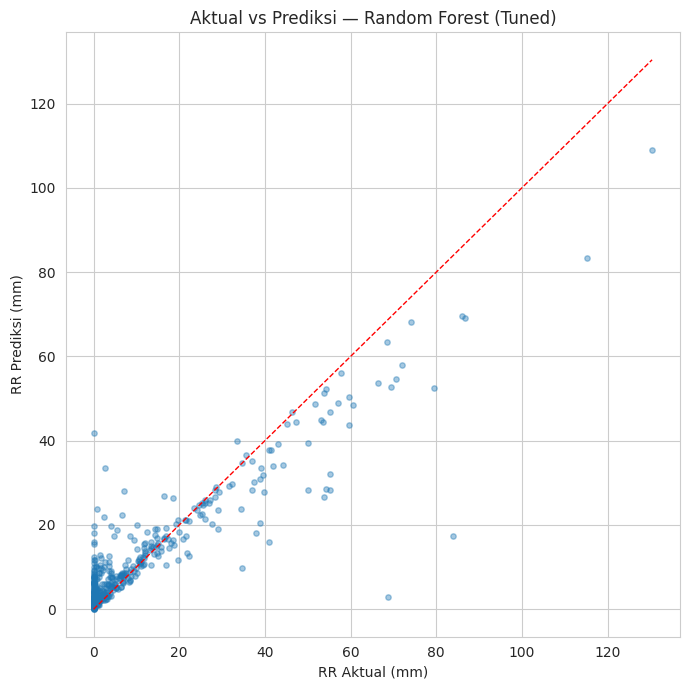

In [37]:
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(y_test, y_pred, alpha=0.4, s=15)
lim = max(y_test.max(), y_pred.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
ax.set_xlabel('RR Aktual (mm)')
ax.set_ylabel('RR Prediksi (mm)')
ax.set_title('Aktual vs Prediksi — Random Forest (Tuned)')
plt.tight_layout()
plt.show()


## 5.2 Validasi Tambahan: Evaluasi Khusus pada BMKG_OBSERVASI

Ini metrik yang **paling jujur** untuk mengukur performa di dunia nyata, karena hanya memakai baris pengukuran langsung BMKG (bukan hasil augmentasi statistik).

In [38]:
mask_obs_test = sumber_test.values == 'BMKG_OBSERVASI'
print('Jumlah data uji BMKG_OBSERVASI:', mask_obs_test.sum(), 'dari total', len(y_test), 'data uji')

if mask_obs_test.sum() > 0:
    mae_obs = mean_absolute_error(y_test[mask_obs_test], y_pred[mask_obs_test])
    rmse_obs = np.sqrt(mean_squared_error(y_test[mask_obs_test], y_pred[mask_obs_test]))
    r2_obs = r2_score(y_test[mask_obs_test], y_pred[mask_obs_test])
    print(f'MAE  (BMKG_OBSERVASI only) : {mae_obs:.3f} mm')
    print(f'RMSE (BMKG_OBSERVASI only) : {rmse_obs:.3f} mm')
    print(f'R2   (BMKG_OBSERVASI only) : {r2_obs:.3f}')
else:
    print('Tidak ada data BMKG_OBSERVASI pada test set.')


Jumlah data uji BMKG_OBSERVASI: 439 dari total 439 data uji
MAE  (BMKG_OBSERVASI only) : 4.555 mm
RMSE (BMKG_OBSERVASI only) : 8.376 mm
R2   (BMKG_OBSERVASI only) : 0.805


**Catatan penting:** karena split berbasis kronologis dan data `BMKG_OBSERVASI` berada di ujung akhir garis waktu (Jul 2024 – Jan 2026), data uji otomatis didominasi baris observasi asli. Ini membuat R² keseluruhan dan R² khusus observasi nyaris identik — evaluasi yang dilaporkan representatif untuk data pengukuran nyata, bukan tertutupi rata-rata dari data augmentasi.

## 5.3 Feature Importance

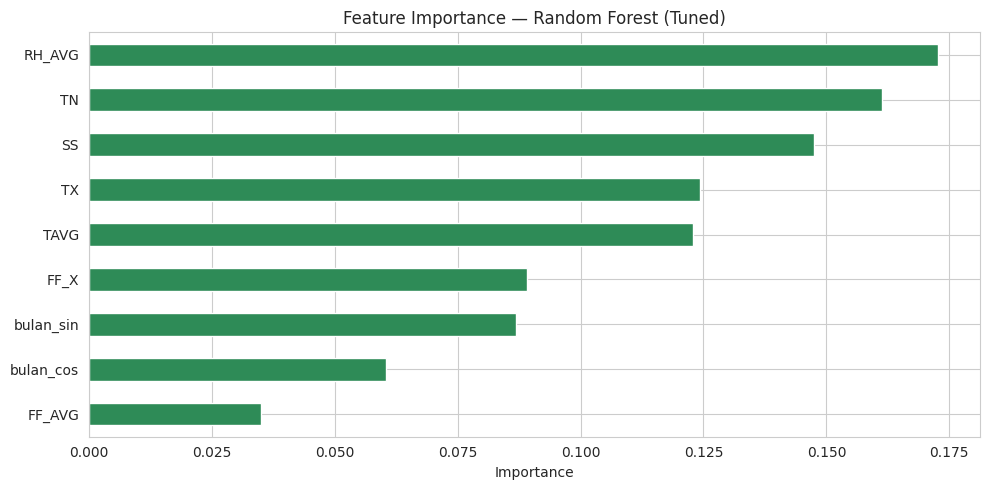

,0
RH_AVG,0.172603
TN,0.161337
SS,0.147489
TX,0.124234
TAVG,0.122851
FF_X,0.089188
bulan_sin,0.086803
bulan_cos,0.060421
FF_AVG,0.035074


In [39]:
importances = pd.Series(model_rf.feature_importances_, index=fitur).sort_values(ascending=False)

fig, ax = plt.subplots()
importances.plot(kind='barh', ax=ax, color='seagreen')
ax.invert_yaxis()
ax.set_title('Feature Importance — Random Forest (Tuned)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

importances


---
# FASE 6 — Deployment

## 6.1 Simpan Model Final

In [40]:
import joblib

MODEL_PATH = 'model_random_forest_curah_hujan_sukabumi.joblib'
joblib.dump(model_rf, MODEL_PATH)
print(f'Model disimpan ke: {MODEL_PATH}')
print(f'Konfigurasi final: {best_cfg}')


Model disimpan ke: model_random_forest_curah_hujan_sukabumi.joblib
Konfigurasi final: {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 1, 'max_features': 0.5}


## 6.2 Contoh Fungsi Prediksi

In [41]:
def prediksi_curah_hujan(tn, tx, tavg, rh_avg, ss, ff_x, ff_avg, bulan, model=model_rf):
    """Prediksi curah hujan harian (mm) dari variabel cuaca."""
    bulan_sin = np.sin(2 * np.pi * bulan / 12)
    bulan_cos = np.cos(2 * np.pi * bulan / 12)
    X_baru = pd.DataFrame([{
        'TN': tn, 'TX': tx, 'TAVG': tavg, 'RH_AVG': rh_avg,
        'SS': ss, 'FF_X': ff_x, 'FF_AVG': ff_avg,
        'bulan_sin': bulan_sin, 'bulan_cos': bulan_cos
    }])
    return model.predict(X_baru)[0]

contoh_prediksi = prediksi_curah_hujan(tn=22.5, tx=31.0, tavg=26.5, rh_avg=85, ss=3.0, ff_x=10, ff_avg=2, bulan=1)
print(f'Contoh prediksi RR: {contoh_prediksi:.2f} mm')


Contoh prediksi RR: 8.79 mm


## 6.3 Ringkasan & Catatan untuk Laporan/Skripsi

**Sumber data:** seluruh dataset bersumber dari BMKG — baik `BMKG_OBSERVASI` (pengukuran langsung) maupun `BMKG_AUGMENTASI` (estimasi statistik yang dibangun dari pola musiman `BMKG_OBSERVASI`, bukan dikarang bebas).

**Keterbatasan yang wajib disebutkan di laporan:**
- ±75% data (2020 – pertengahan 2024) adalah `BMKG_AUGMENTASI`, bukan pengukuran lapangan langsung.
- Skor R² **BMKG_OBSERVASI-only** (bagian 5.2) disarankan jadi acuan utama kesimpulan penelitian, bukan skor keseluruhan yang tercampur data augmentasi.
- Kolom `SUMBER` di dataset final memungkinkan validasi ini diulang kapan saja (misalnya kalau data observasi BMKG bertambah di masa depan).